In [5]:
# --- IMPORT STATEMENTS ---

import numpy as np

import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS

import healpy as hp

In [6]:
LINUX_DIRECTORY = "/home/aimee/mphys"
MAPS_DIR = f'{LINUX_DIRECTORY}/data/masked_maps'
FILE_NAME = 'comap_alr-2_galactic_301025_band00_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19_masked.fits'

SAVE_FIGS = False

In [7]:
def get_map(path):
    
    print(f"Getting data from {path}")
    fits_file = fits.open(path)

    data = fits_file[0].data
    header = fits_file[0].header
    wcs = WCS(header)

    noise_original = fits_file[1].data
    noise_5_arcmin = fits_file[2].data
    noise_10_arcmin = fits_file[3].data
        
    return data, noise_original, noise_5_arcmin, noise_10_arcmin, header, wcs

In [8]:
def plot_fits(fits_data, projection, x_coords=[], y_coords=[], title='Title', save_figs=SAVE_FIGS):
    
    fits_data = np.where(fits_data == hp.UNSEEN, np.nan, fits_data) # convert hp.UNSEEN to np.nan for plotting
    
    vmin = 0 #np.nanpercentile(fits_data, 0.)
    vmax = np.nanpercentile(fits_data, 99.5)

    fig, ax = plt.subplots(1, 1, figsize=(13,2), dpi=300,
                            subplot_kw={'projection':projection})

    im = ax.imshow(fits_data, origin='lower', cmap='viridis', vmin=vmin , vmax=vmax)
    
    if x_coords is not None and y_coords is not None: # optional: plot provided coordinates over image
        ax.plot(x_coords, y_coords, 'rx', markersize=3)
    
    ax.set_title(title)
    ax.set_xlabel(r"$l$ [degrees]")
    ax.set_ylabel(r"$b$ [degrees]")

    cbar = fig.colorbar(im, ax=ax, orientation='vertical')
    cbar.set_label(r"$T_b$ [K]")

    fig.subplots_adjust(left=0.07, right=0.88, top=0.95, bottom=0.05, hspace=0.4)
    plt.tight_layout()

    if save_figs:
        plt.savefig(f"{LINUX_DIRECTORY}/{FIGURE_SAVEDIR}/{title.replace(' ', '_')}.png", dpi=300)
    
    plt.show()

Getting data from /home/aimee/mphys/data/masked_maps/comap_alr-2_galactic_301025_band00_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19_masked.fits


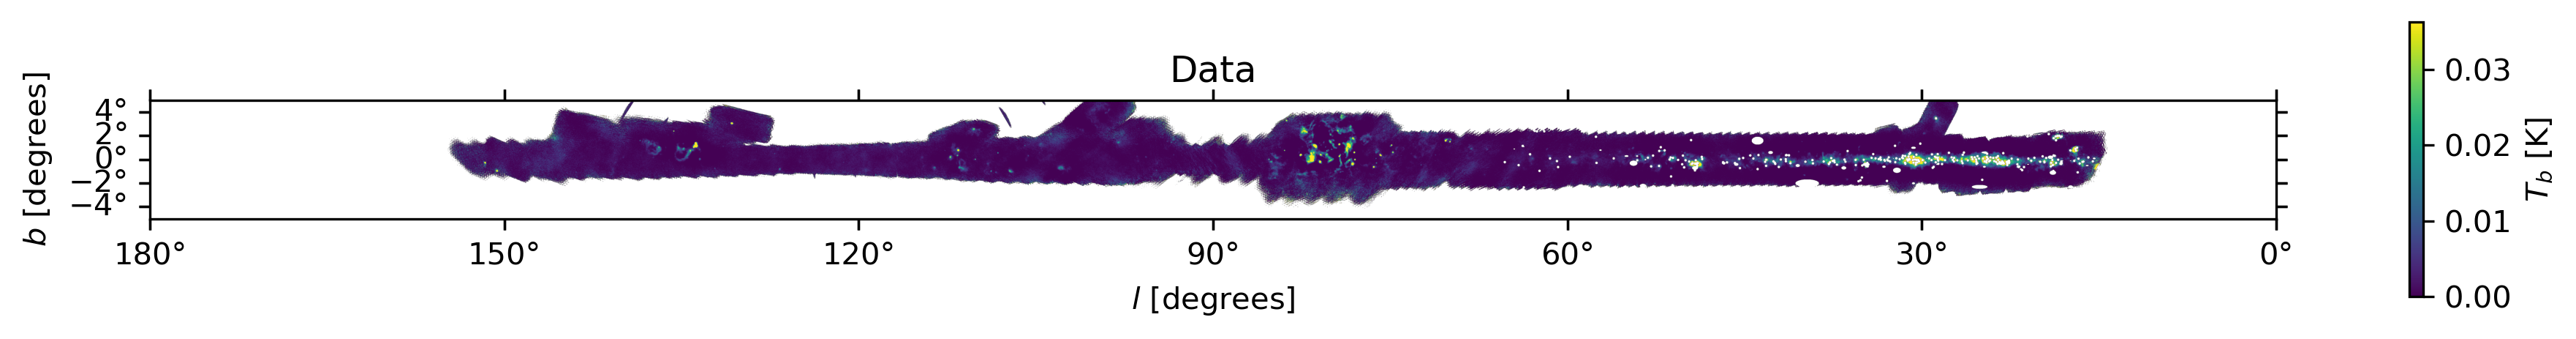

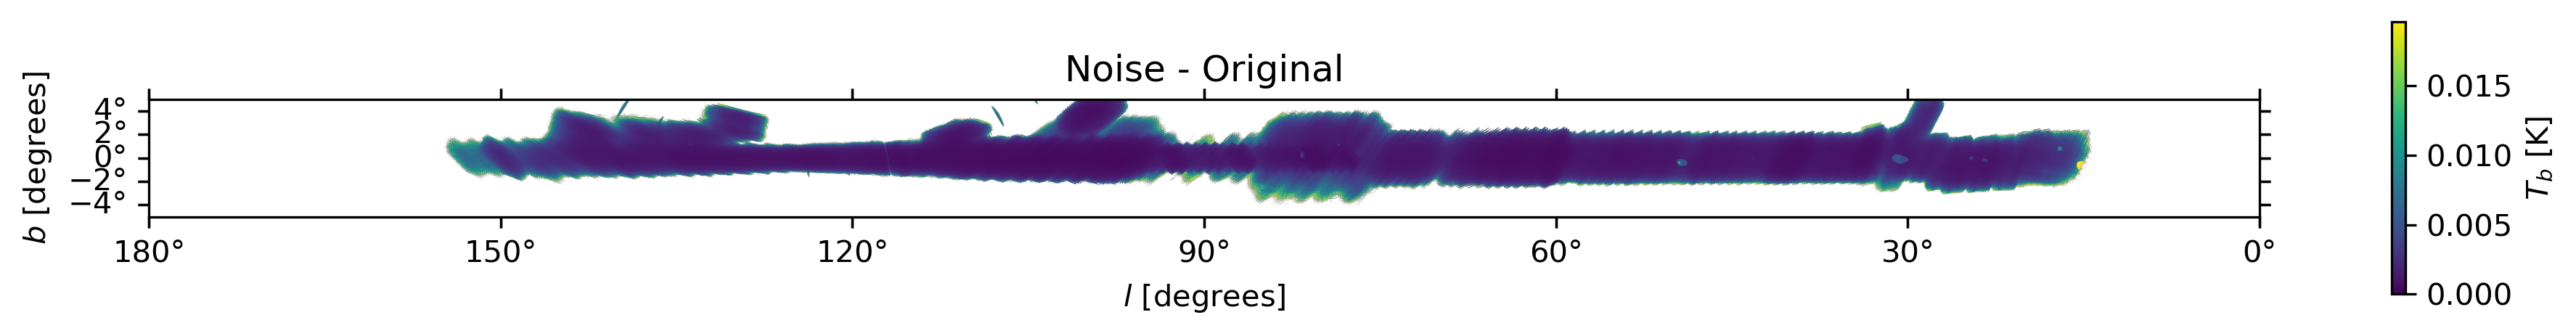

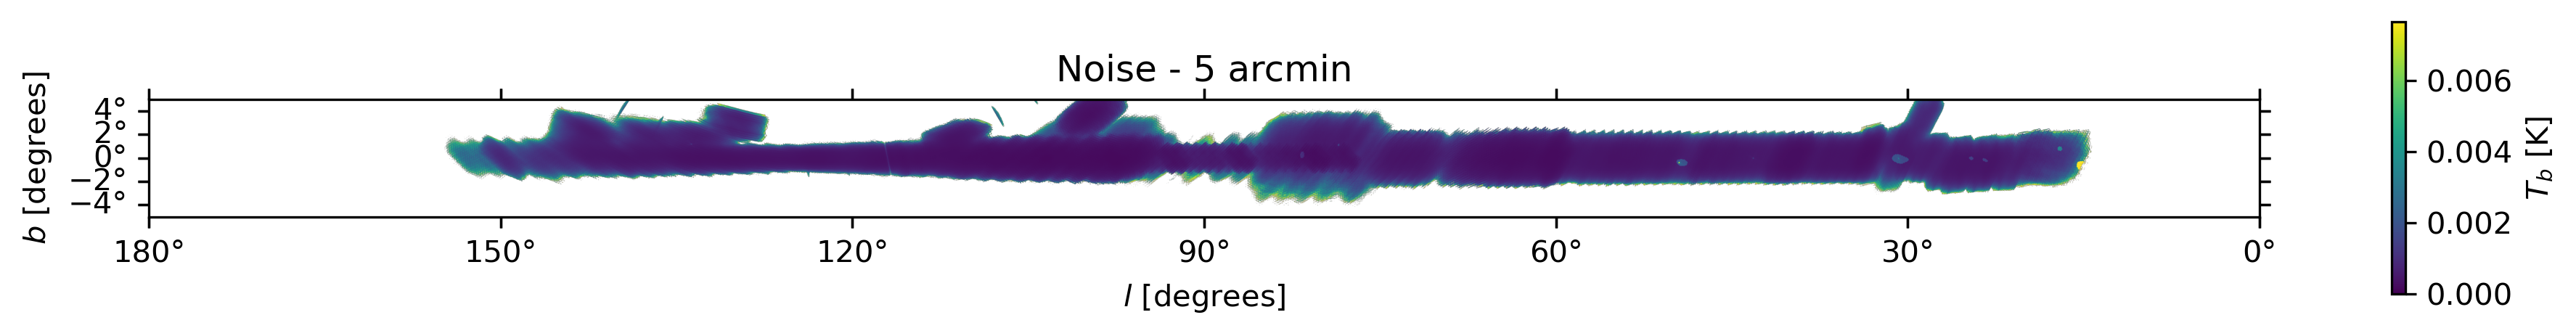

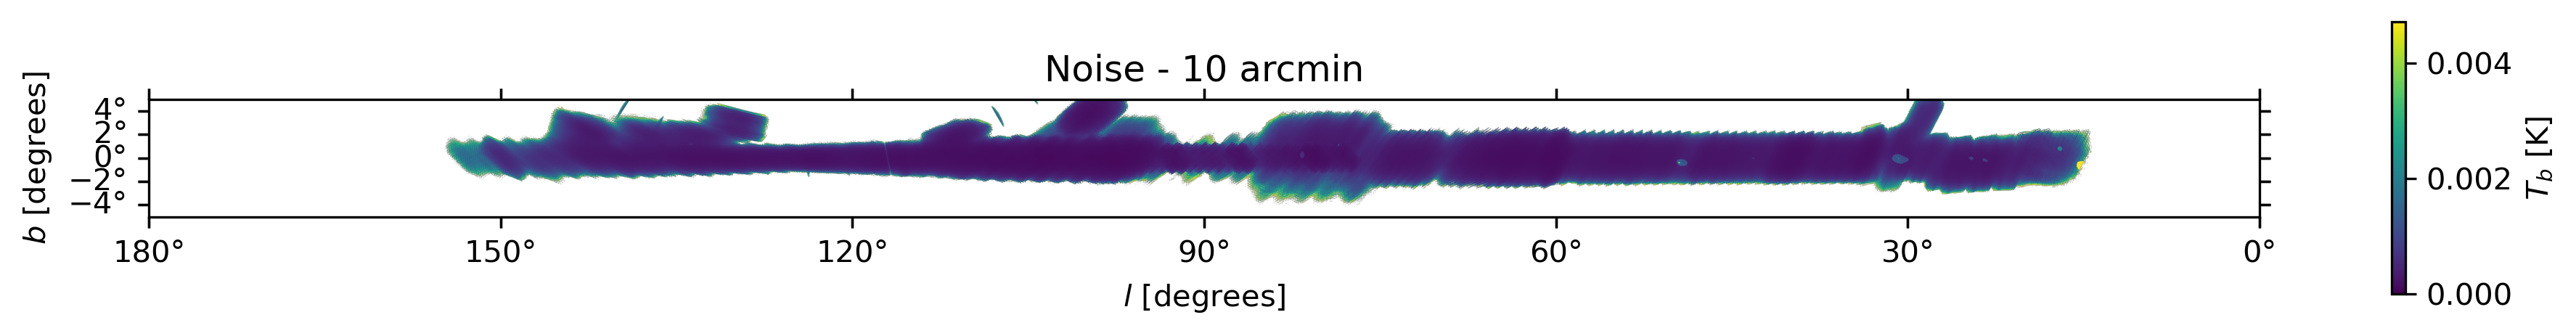

In [9]:
data, noise_original, noise_5_arcmin, noise_10_arcmin, header, wcs = get_map(f'{MAPS_DIR}/{FILE_NAME}')

plot_fits(data, wcs, title='Data')
plot_fits(noise_original, wcs, title='Noise - Original')
plot_fits(noise_5_arcmin, wcs, title='Noise - 5 arcmin')
plot_fits(noise_10_arcmin, wcs, title='Noise - 10 arcmin')